Churn Prediction 

In [ ]:
import pandas as pd
import numpy as np
from faker import Faker
import random


fake = Faker()
np.random.seed(42)
random.seed(42)

num_records = 1500


cities = ['Lahore', 'Islamabad', 'Mardan', 'Peshawar', 'Karachi']
subscription_types = ['Basic', 'Standard', 'Premium']
genders = ['Male', 'Female']

data_list = []

for i in range(num_records):
   
    customer_id = f"CUST-{1000 + i}"
    age = int(np.random.randint(18, 70))
    gender = random.choice(genders)
    city = random.choice(cities)
    subscription = random.choice(subscription_types)
    
    
    tenure = int(np.random.randint(1, 60)) # 1 to 60 months
    if subscription == 'Basic':
        monthly_spending = round(float(np.random.uniform(15.0, 40.0)), 2)
    elif subscription == 'Standard':
        monthly_spending = round(float(np.random.uniform(41.0, 80.0)), 2)
    else:
        monthly_spending = round(float(np.random.uniform(81.0, 150.0)), 2)
        
    
    login_frequency = int(np.random.randint(1, 30)) 
    num_purchases = int(np.random.randint(0, 15))
    
    
    risk_factor = 0.0
    if age > 50: risk_factor += 0.1
    if tenure < 6: risk_factor += 0.25
    if monthly_spending > 100: risk_factor += 0.15 
    
    
    base_requests = np.random.randint(0, 5)
    customer_support_requests = int(base_requests + 2 if risk_factor > 0.3 else base_requests)
    
    
    if customer_support_requests >= 4:
        satisfaction_score = int(np.random.choice([1, 2, 3], p=[0.5, 0.3, 0.2]))
        risk_factor += 0.3
    else:
        satisfaction_score = int(np.random.choice([3, 4, 5], p=[0.2, 0.5, 0.3]))
        
    
    last_activity_date = fake.date_between(start_date='-30d', end_date='today').strftime('%Y-%m-%d')
    
    
    churn_probability = min(max(0.1 + risk_factor, 0.0), 0.95)
    churn_status = int(np.random.choice([0, 1], p=[1 - churn_probability, churn_probability]))
    
    
    data_list.append([
        customer_id, age, gender, city, subscription, monthly_spending,
        tenure, num_purchases, customer_support_requests, login_frequency,
        last_activity_date, satisfaction_score, churn_status
    ])


columns = [
    'Customer ID', 'Age', 'Gender', 'City', 'Subscription Type', 'Monthly Spending',
    'Tenure', 'Number of Purchases', 'Customer Support Requests', 'Login Frequency',
    'Last Activity Date', 'Satisfaction Score', 'Churn Status'
]
df_churn = pd.DataFrame(data_list, columns=columns)


df_churn.to_csv('customer_churn_dataset.csv', index=False)
print(f"Dataset successfully created with {df_churn.shape[0]} rows and saved to 'customer_churn_dataset.csv'!")

Dataset successfully created with 1500 rows and saved to 'customer_churn_dataset.csv'!


In [4]:
df_churn.head(5)

,Customer ID,Age,Gender,City,Subscription Type,Monthly Spending,Tenure,Number of Purchases,Customer Support Requests,Login Frequency,Last Activity Date,Satisfaction Score,Churn Status
0,CUST-1000,56,Male,Lahore,Premium,146.60,52,7,4,11,2026-05-28,2,1
1,CUST-1001,40,Female,Islamabad,Basic,26.48,11,3,2,21,2026-06-07,3,1
2,CUST-1002,61,Male,Lahore,Premium,95.65,30,4,0,28,2026-06-22,4,0
3,CUST-1003,61,Male,Karachi,Standard,52.36,25,14,1,27,2026-06-19,3,1
4,CUST-1004,32,Male,Lahore,Basic,30.46,47,6,3,12,2026-06-17,4,0


In [5]:
print(f"Dataset Dimensions: {df_churn.shape[0]} rows, {df_churn.shape[1]} columns\n")

Dataset Dimensions: 1500 rows, 13 columns



In [6]:
print(df_churn.isnull().sum())

Customer ID                  0
Age                          0
Gender                       0
City                         0
Subscription Type            0
Monthly Spending             0
Tenure                       0
Number of Purchases          0
Customer Support Requests    0
Login Frequency              0
Last Activity Date           0
Satisfaction Score           0
Churn Status                 0
dtype: int64


In [7]:
duplicate_count = df_churn.duplicated().sum()
print(f"Total Duplicate Rows Found: {duplicate_count}")

Total Duplicate Rows Found: 0


In [8]:
df_churn.head(5)

,Customer ID,Age,Gender,City,Subscription Type,Monthly Spending,Tenure,Number of Purchases,Customer Support Requests,Login Frequency,Last Activity Date,Satisfaction Score,Churn Status
0,CUST-1000,56,Male,Lahore,Premium,146.60,52,7,4,11,2026-05-28,2,1
1,CUST-1001,40,Female,Islamabad,Basic,26.48,11,3,2,21,2026-06-07,3,1
2,CUST-1002,61,Male,Lahore,Premium,95.65,30,4,0,28,2026-06-22,4,0
3,CUST-1003,61,Male,Karachi,Standard,52.36,25,14,1,27,2026-06-19,3,1
4,CUST-1004,32,Male,Lahore,Basic,30.46,47,6,3,12,2026-06-17,4,0


Feature Engineering


In [9]:



print("Original Columns Count:", df_churn.shape[1])

df_churn['Cost_Per_Purchase'] = df_churn['Monthly Spending'] / (df_churn['Number of Purchases'] + 1)
df_churn['Support_To_Login_Ratio'] = df_churn['Customer Support Requests'] / (df_churn['Login Frequency'] + 1)
df_churn['Value_Score'] = (df_churn['Tenure'] * df_churn['Satisfaction Score']) / (df_churn['Monthly Spending'] + 1)
df_churn['Purchase_Velocity'] = df_churn['Number of Purchases'] / df_churn['Tenure']
df_churn['Is_Frustrated_New_Customer'] = ((df_churn['Tenure'] < 6) & (df_churn['Satisfaction Score'] <= 2)).astype(int)

print("New Columns Count:", df_churn.shape[1])
print("\nPreviewing engineered features for the first 3 rows:")
print(df_churn[['Customer ID', 'Cost_Per_Purchase', 'Support_To_Login_Ratio', 'Value_Score', 'Is_Frustrated_New_Customer']].head(3))

Original Columns Count: 13
New Columns Count: 18

Previewing engineered features for the first 3 rows:
  Customer ID  Cost_Per_Purchase  Support_To_Login_Ratio  Value_Score  \
0   CUST-1000             18.325                0.333333     0.704607   
1   CUST-1001              6.620                0.090909     1.200873   
2   CUST-1002             19.130                0.000000     1.241593   

   Is_Frustrated_New_Customer  
0                           0  
1                           0  
2                           0  


Categorical encoding

In [10]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

le_sub = LabelEncoder()
df_churn['Subscription Type'] = le_sub.fit_transform(df_churn['Subscription Type'])

df_churn = pd.get_dummies(df_churn, columns=['Gender', 'City'], dtype=int)

print("Columns after categorical encoding:")
print(df_churn.dtypes)
print("\nShape of updated dataset:", df_churn.shape)

Columns after categorical encoding:
Customer ID                    object
Age                             int64
Subscription Type               int64
Monthly Spending              float64
Tenure                          int64
Number of Purchases             int64
Customer Support Requests       int64
Login Frequency                 int64
Last Activity Date             object
Satisfaction Score              int64
Churn Status                    int64
Cost_Per_Purchase             float64
Support_To_Login_Ratio        float64
Value_Score                   float64
Purchase_Velocity             float64
Is_Frustrated_New_Customer      int64
Gender_Female                   int64
Gender_Male                     int64
City_Islamabad                  int64
City_Karachi                    int64
City_Lahore                     int64
City_Mardan                     int64
City_Peshawar                   int64
dtype: object

Shape of updated dataset: (1500, 23)


In [11]:
print("==============================================")
print("          TARGET CLASS BALANCE CHECK          ")
print("==============================================")

raw_counts = df_churn['Churn Status'].value_counts()
percentage_counts = df_churn['Churn Status'].value_counts(normalize=True) * 100

print("Raw Customer Counts:")
print(raw_counts)
print("\nPercentage Breakdown:")
print(percentage_counts)
print("==============================================")

          TARGET CLASS BALANCE CHECK          
Raw Customer Counts:
Churn Status
0    1117
1     383
Name: count, dtype: int64

Percentage Breakdown:
Churn Status
0    74.466667
1    25.533333
Name: proportion, dtype: float64


Test Train Split

In [12]:
from sklearn.model_selection import train_test_split

features_to_keep = [
    'Tenure', 
    'Cost_Per_Purchase', 
    'Support_To_Login_Ratio', 
    'Value_Score', 
    'Purchase_Velocity', 
    'Is_Frustrated_New_Customer'
]

X = df_churn[features_to_keep]
y = df_churn['Churn Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Features included in X_train:")
print(X_train.columns.tolist())
print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Features included in X_train:
['Tenure', 'Cost_Per_Purchase', 'Support_To_Login_Ratio', 'Value_Score', 'Purchase_Velocity', 'Is_Frustrated_New_Customer']

X_train shape: (1200, 6)
X_test shape: (300, 6)


Class Balancing

In [13]:
from imblearn.over_sampling import SMOTE
print("Before balancing (y_train):")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nAfter balancing (y_train_balanced):")
print(y_train_balanced.value_counts())
print("\nBalanced training features shape:", X_train_balanced.shape)
data_frame_for_visualization= pd.concat([X_train_balanced, y_train_balanced], axis=1)

Before balancing (y_train):
Churn Status
0    894
1    306
Name: count, dtype: int64

After balancing (y_train_balanced):
Churn Status
0    894
1    894
Name: count, dtype: int64

Balanced training features shape: (1788, 6)


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preparation complete!")
print("First transformed training row sample:\n", X_train_scaled[0])

Data Preparation complete!
First transformed training row sample:
 [ 0.14920762 -0.5129264  -0.6026933   2.03159065 -0.33366204 -0.14881703]


Exploratory Data Analysis

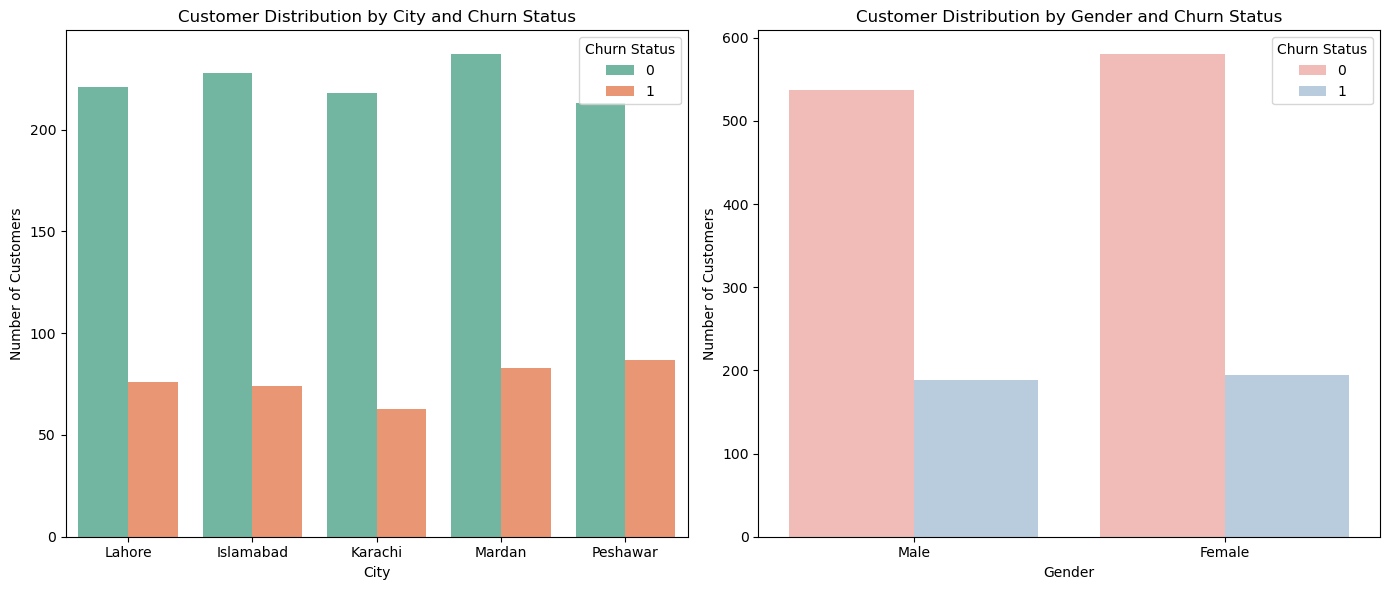

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load a fresh copy with original text columns for charting
df_eda = pd.read_csv('customer_churn_dataset.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: City Chart
sns.countplot(ax=axes[0], data=df_eda, x='City', hue='Churn Status', palette='Set2')
axes[0].set_title('Customer Distribution by City and Churn Status')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Number of Customers')

# Plot 2: Gender Chart
sns.countplot(ax=axes[1], data=df_eda, x='Gender', hue='Churn Status', palette='Pastel1')
axes[1].set_title('Customer Distribution by Gender and Churn Status')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

Monthly Spending Distribution across Subscription Tiers

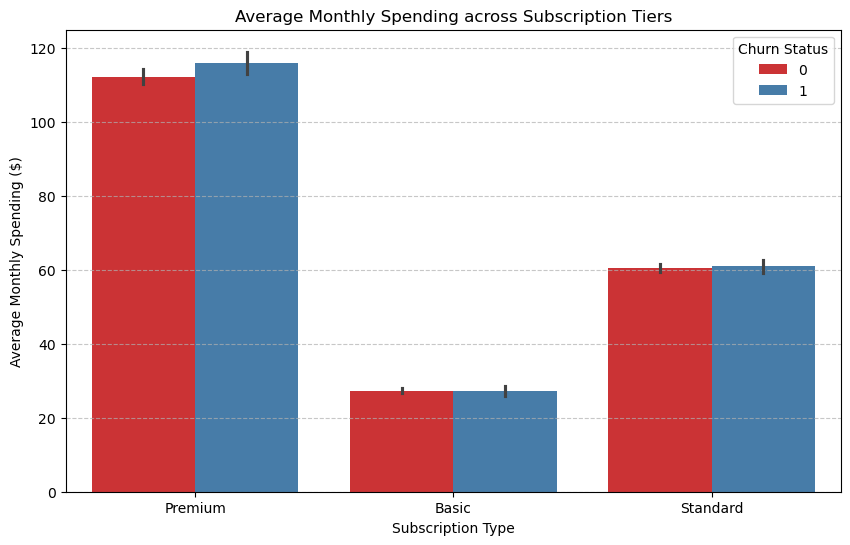

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# CHANGED: swapped sns.boxplot for sns.barplot
sns.barplot(data=df_eda, x='Subscription Type', y='Monthly Spending', hue='Churn Status', palette='Set1')

plt.title('Average Monthly Spending across Subscription Tiers')
plt.xlabel('Subscription Type')
plt.ylabel('Average Monthly Spending ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Overall Customer Churn Distribution

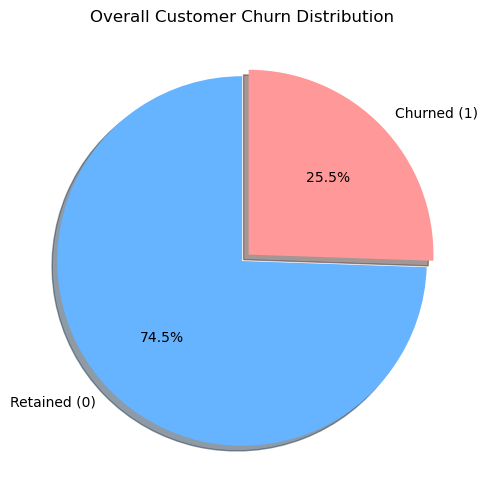

In [17]:
import matplotlib.pyplot as plt

churn_counts = df_churn['Churn Status'].value_counts()
labels = ['Retained (0)', 'Churned (1)']
colors = ['#66b3ff', '#ff9999']

plt.figure(figsize=(6, 6))
plt.pie(
    churn_counts, 
    labels=labels, 
    colors=colors, 
    autopct='%1.1f%%', 
    startangle=90, 
    explode=(0, 0.05), 
    shadow=True
)

plt.title('Overall Customer Churn Distribution')
plt.show()

Feature Relationships

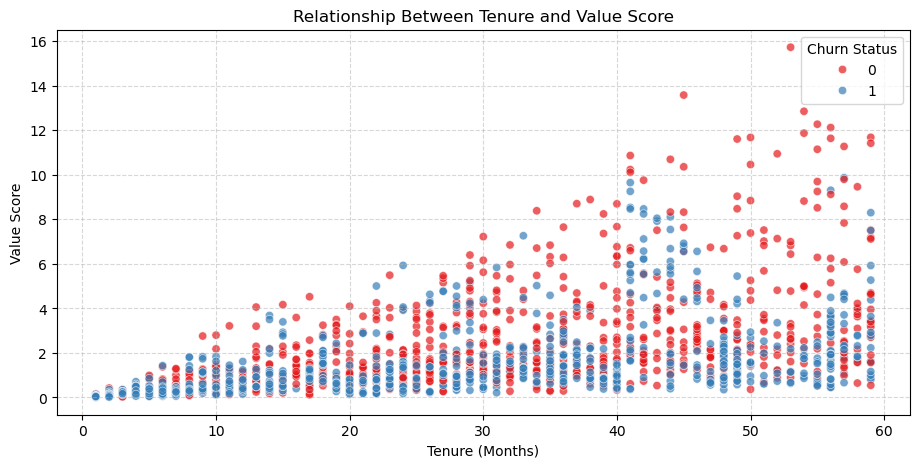

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11, 5))

sns.scatterplot(
    data=data_frame_for_visualization, 
    x='Tenure', 
    y='Value_Score', 
    hue='Churn Status', 
    palette='Set1', 
    alpha=0.7
)

plt.title('Relationship Between Tenure and Value Score')
plt.xlabel('Tenure (Months)')
plt.ylabel('Value Score')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

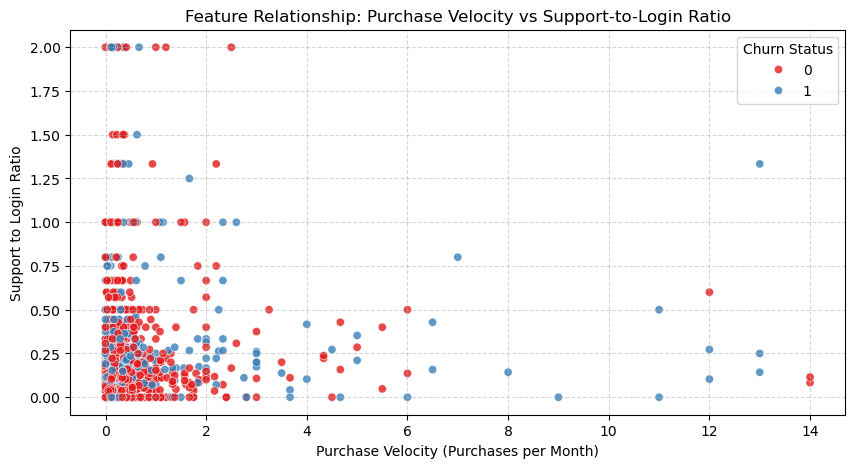

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df_churn, 
    x='Purchase_Velocity', 
    y='Support_To_Login_Ratio', 
    hue='Churn Status', 
    palette='Set1', 
    alpha=0.8
)

plt.title('Feature Relationship: Purchase Velocity vs Support-to-Login Ratio')
plt.xlabel('Purchase Velocity (Purchases per Month)')
plt.ylabel('Support to Login Ratio')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

<Figure size 800x300 with 0 Axes>

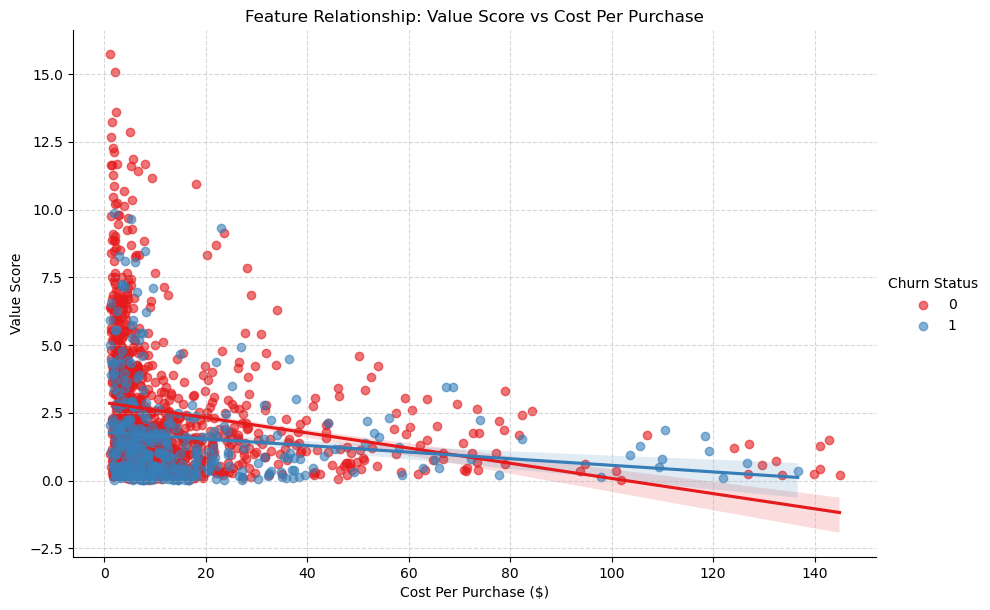

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 3))


sns.lmplot(
    data=df_churn, 
    x='Cost_Per_Purchase', 
    y='Value_Score', 
    hue='Churn Status', 
    palette='Set1', 
    height=6, 
    aspect=1.5,
    scatter_kws={'alpha': 0.6}
)

plt.title('Feature Relationship: Value Score vs Cost Per Purchase')
plt.xlabel('Cost Per Purchase ($)')
plt.ylabel('Value Score')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Corelation Analysis

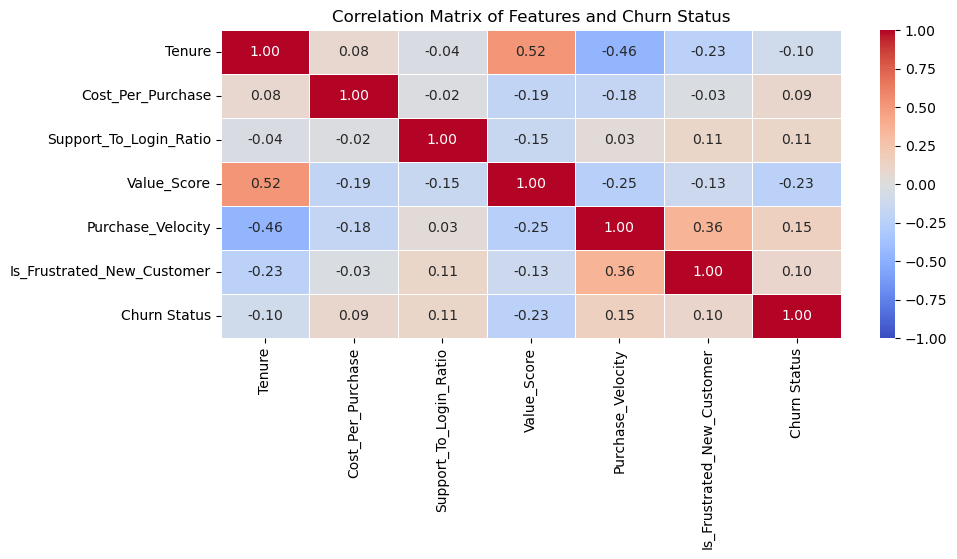

Exact Correlation Scores with Churn Status (Sorted):
Churn Status                  1.000000
Purchase_Velocity             0.153453
Support_To_Login_Ratio        0.105691
Is_Frustrated_New_Customer    0.095722
Cost_Per_Purchase             0.088107
Tenure                       -0.100199
Value_Score                  -0.230939
Name: Churn Status, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


df_corr_analysis = pd.concat([X_train_balanced, y_train_balanced], axis=1)


corr_matrix = df_corr_analysis.corr()


plt.figure(figsize=(10, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Features and Churn Status')
plt.show()

print("Exact Correlation Scores with Churn Status (Sorted):")
print(corr_matrix['Churn Status'].sort_values(ascending=False))

Customer behavior trends

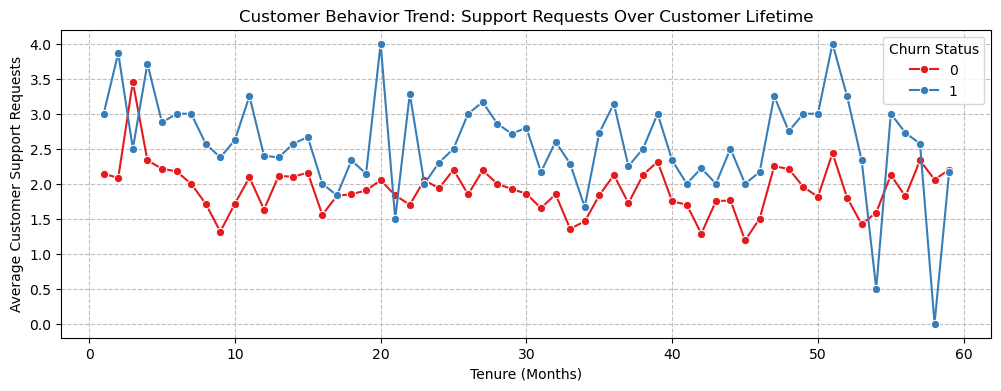

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))


sns.lineplot(
    data=df_eda, 
    x='Tenure', 
    y='Customer Support Requests', 
    hue='Churn Status', 
    palette='Set1', 
    marker='o',
    errorbar=None 
)
plt.title('Customer Behavior Trend: Support Requests Over Customer Lifetime')
plt.xlabel('Tenure (Months)')
plt.ylabel('Average Customer Support Requests')
plt.grid(True, linestyle='--', alpha=0.8)

plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler


selected_features = [
    'Purchase_Velocity', 
    'Support_To_Login_Ratio', 
    'Is_Frustrated_New_Customer', 
    'Cost_Per_Purchase'
]


X_train_refined = X_train_balanced[selected_features]
X_test_refined = X_test[selected_features]


scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_refined)
X_test_final = scaler.transform(X_test_refined)

print("==============================================")
print("        FINAL MODEL TRAINING MATRICES         ")
print("==============================================")
print("Final Training Features Shape:", X_train_final.shape)
print("Final Testing Features Shape :", X_test_final.shape)
print("\nFeatures being fed to the model:", selected_features)
print("==============================================")

        FINAL MODEL TRAINING MATRICES         
Final Training Features Shape: (1788, 4)
Final Testing Features Shape : (300, 4)

Features being fed to the model: ['Purchase_Velocity', 'Support_To_Login_Ratio', 'Is_Frustrated_New_Customer', 'Cost_Per_Purchase']


Machine Learning Model

       RANDOM FOREST PERFORMANCE              
              precision    recall  f1-score   support

           0       0.79      0.75      0.77       223
           1       0.38      0.43      0.40        77

    accuracy                           0.67       300
   macro avg       0.58      0.59      0.59       300
weighted avg       0.69      0.67      0.68       300

Random Forest Classifier Accuracy: 67.00%



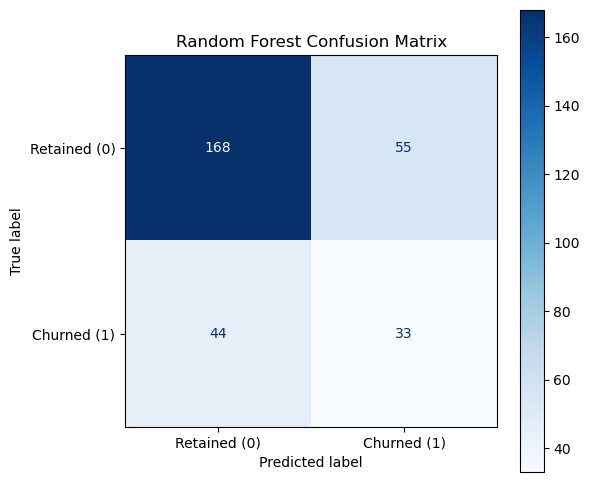

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_final, y_train_balanced)
rf_preds = rf_model.predict(X_test_final)

print("==============================================")
print("       RANDOM FOREST PERFORMANCE              ")
print("==============================================")
print(classification_report(y_test, rf_preds))
print(f"Random Forest Classifier Accuracy: {accuracy_score(y_test, rf_preds):.2%}\n")


cm = confusion_matrix(y_test, rf_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained (0)', 'Churned (1)'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Random Forest Confusion Matrix')
plt.show()

          XGBOOST PERFORMANCE                 
              precision    recall  f1-score   support

           0       0.78      0.73      0.76       223
           1       0.35      0.42      0.38        77

    accuracy                           0.65       300
   macro avg       0.57      0.57      0.57       300
weighted avg       0.67      0.65      0.66       300

XGBoost Accuracy: 65.00%



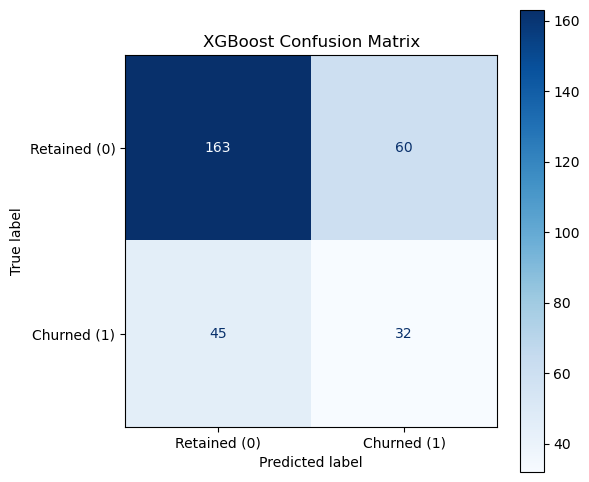

In [ ]:
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

xgb_model = XGBClassifier(random_state=42, n_estimators=100, eval_metric='logloss')
xgb_model.fit(X_train_final, y_train_balanced)
xgb_preds = xgb_model.predict(X_test_final)

print("==============================================")
print("          XGBOOST PERFORMANCE                 ")
print("==============================================")
print(classification_report(y_test, xgb_preds))
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds):.2%}\n")


cm = confusion_matrix(y_test, xgb_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained (0)', 'Churned (1)'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('XGBoost Confusion Matrix')
plt.show()

Interface Design

In [ ]:
import gradio as gr
import pandas as pd

def predict_customer_churn(purchase_val, support_ratio, is_frustrated, cost_per_purch):
    raw_inputs = pd.DataFrame([{
        'Purchase_Velocity': float(purchase_val),
        'Support_To_Login_Ratio': float(support_ratio),
        'Is_Frustrated_New_Customer': 1.0 if is_frustrated == "Yes" else 0.0,
        'Cost_Per_Purchase': float(cost_per_purch)
    }])
    
    scaled_inputs = scaler.transform(raw_inputs)
    pred_class = xgb_model.predict(scaled_inputs)[0]
    
    if pred_class == 1:
        return "⚠️ CHURN"
    else:
        return "✅ NOT CHURN"

interface = gr.Interface(
    fn=predict_customer_churn,
    inputs=[
        gr.Number(value=2.5, label="Purchase Velocity (Range: 0.0 to 10.0)"),
        gr.Number(value=0.8, label="Support-to-Login Ratio (Range: 0.0 to 5.0)"),
        gr.Dropdown(choices=["No", "Yes"], value="No", label="Is Frustrated New Customer?"),
        gr.Number(value=45.0, label="Cost Per Purchase ($) (Range: 5.0 to 250.0)")
    ],
    outputs=gr.Textbox(label="Final Prediction Status"),
    title="🔮 Customer Churn Prediction Interface",
    description="Enter the customer metrics to see an instant classification result.",
    theme="soft"
)

interface.launch(share=False)

c:\Users\DELL\anaconda3\Lib\site-packages\gradio\interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


c:\Users\DELL\anaconda3\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
c:\Users\DELL\anaconda3\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
c:\Users\DELL\anaconda3\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
c:\Users\DELL\anaconda3\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
c:\Users\DELL\anacon